In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import cv2


# JPEG Compression and Decompression in Python

This notebook implements a simplified JPEG-like codec. It includes color-space conversion, chroma subsampling, block processing, DCT, quantization, DPCM, zig-zag scanning, run-length encoding, Huffman coding, decompression, and quality evaluation.


## [1] Image Loading


In [2]:
def ler_imagem(caminho_imagem):
    """Load an image with OpenCV and convert it from BGR to RGB."""
    imagem_bgr = cv2.imread(str(caminho_imagem))

    if imagem_bgr is None:
        raise FileNotFoundError(f"Image not found: {caminho_imagem}")

    imagem_rgb = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)
    plt.imshow(imagem_rgb)
    plt.title("Input image")
    plt.axis("off")
    plt.show()
    return imagem_rgb


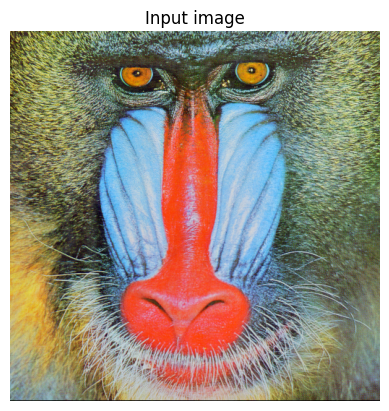

In [3]:
# Use a relative path so the notebook works after cloning the GitHub repository.
image_path = Path("data/input/sample_image.png")
imagem_rgb = ler_imagem(image_path)


## [2] RGB to YCbCr Conversion


In [4]:
def rgb_para_ycbcr(imagem_rgb):
    # Convert to float to avoid issues with decimal operations
    imagem_rgb = imagem_rgb.astype(np.float64)

    # Split RGB channels
    R = imagem_rgb[:, :, 0]
    G = imagem_rgb[:, :, 1]
    B = imagem_rgb[:, :, 2]

    # RGB -> YCbCr conversion
    Y  =  0.299 * R + 0.587 * G + 0.114 * B
    Cb = -0.168736 * R - 0.331264 * G + 0.5 * B + 128
    Cr =  0.5 * R - 0.418688 * G - 0.081312 * B + 128

    return Y, Cb, Cr


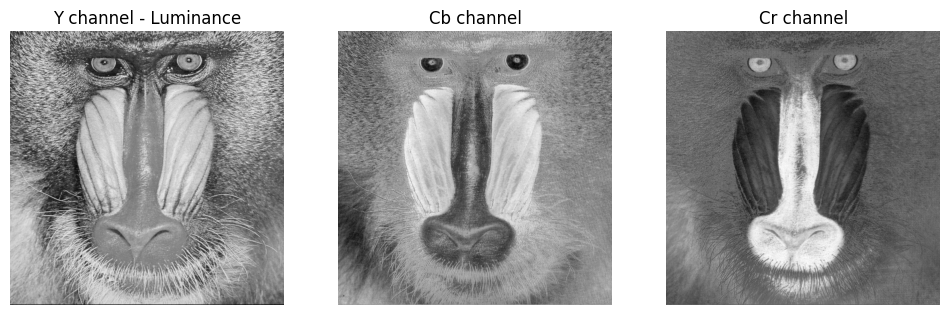

In [5]:
Y, Cb, Cr = rgb_para_ycbcr(imagem_rgb)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(Y, cmap="gray")
plt.title("Y channel - Luminance")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(Cb, cmap="gray")
plt.title("Cb channel")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(Cr, cmap="gray")
plt.title("Cr channel")
plt.axis("off")

plt.show()

In this step, the RGB image is converted to the YCbCr color space. The Y channel represents luminance, or brightness information, while Cb and Cr represent chrominance components. This separation is useful in JPEG compression because the human eye is more sensitive to brightness variations than to color variations. Therefore, the Cb and Cr channels can be subsampled with limited visual impact.


## [3] Chroma Subsampling


In [6]:
def subamostrar_420(Cb, Cr):
    """
    Faz subamostragem 4:2:0 nos canais de crominância Cb e Cr.
    Cada bloco 2x2 vira 1 pixel pela média dos 4 valores.
    """

    Cb_sub = (
        Cb[0::2, 0::2] + Cb[0::2, 1::2] +
        Cb[1::2, 0::2] + Cb[1::2, 1::2]
    ) / 4

    Cr_sub = (
        Cr[0::2, 0::2] + Cr[0::2, 1::2] +
        Cr[1::2, 0::2] + Cr[1::2, 1::2]
    ) / 4

    return Cb_sub, Cr_sub

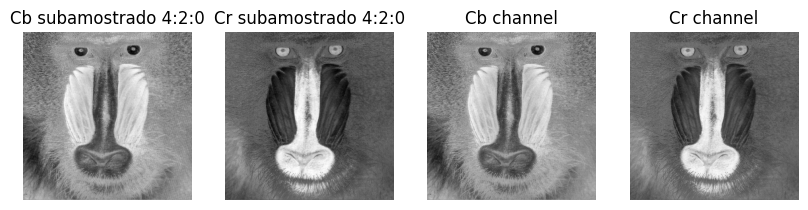

In [7]:
Cb_sub, Cr_sub = subamostrar_420(Cb, Cr)
plt.figure(figsize=(10, 4))

plt.subplot(1, 4, 1)
plt.imshow(Cb_sub, cmap="gray")
plt.title("Cb subamostrado 4:2:0")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(Cr_sub, cmap="gray")
plt.title("Cr subamostrado 4:2:0")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(Cb, cmap="gray")
plt.title("Cb channel")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(Cr, cmap="gray")
plt.title("Cr channel")
plt.axis("off")


plt.show()

In [8]:
#N
print("Y:", Y.shape)
print("Cb original:", Cb.shape)
print("Cr original:", Cr.shape)
print("Cb subamostrado:", Cb_sub.shape)
print("Cr subamostrado:", Cr_sub.shape)

Y: (512, 512)
Cb original: (512, 512)
Cr original: (512, 512)
Cb subamostrado: (256, 256)
Cr subamostrado: (256, 256)


In this step, 4:2:0 chroma subsampling is applied. The Cb and Cr channels are reduced by averaging 2x2 blocks, so each group of four pixels is represented by a single value. The Y channel is kept unchanged because it contains luminance information, to which the human eye is more sensitive.


## [4] Block Conversion


In [9]:
def converter_para_blocos(canal, tamanho_bloco=8):
    """
    Converte uma matriz 2D em uma lista de blocos tamanho_bloco x tamanho_bloco.
    Exemplo: uma matriz 512x512 vira uma lista de blocos 8x8.
    """
    
    blocos = []

    altura, largura = canal.shape

    for i in range(0, altura, tamanho_bloco):
        for j in range(0, largura, tamanho_bloco):
            bloco = canal[i:i+tamanho_bloco, j:j+tamanho_bloco]
            blocos.append(bloco)

    return blocos

In [10]:
blocos_Y = converter_para_blocos(Y)
blocos_Cb = converter_para_blocos(Cb_sub)
blocos_Cr = converter_para_blocos(Cr_sub)

In [11]:
blocos = blocos_Y + blocos_Cb + blocos_Cr

In [12]:
print("Número de blocos Y:", len(blocos_Y))
print("Número de blocos Cb:", len(blocos_Cb))
print("Número de blocos Cr:", len(blocos_Cr))
print("Número total de blocos:", len(blocos))

print("Formato do primeiro bloco Y:", blocos_Y[0].shape)
print("Formato do primeiro bloco Cb:", blocos_Cb[0].shape)
print("Formato do primeiro bloco Cr:", blocos_Cr[0].shape)

Número de blocos Y: 4096
Número de blocos Cb: 1024
Número de blocos Cr: 1024
Número total de blocos: 6144
Formato do primeiro bloco Y: (8, 8)
Formato do primeiro bloco Cb: (8, 8)
Formato do primeiro bloco Cr: (8, 8)


In this step, each image channel is divided into 8x8 blocks. This is necessary because the DCT used in JPEG is applied separately to small image blocks. The Y channel has more blocks because it keeps the original resolution, while the subsampled Cb and Cr channels generate fewer blocks.


## [5] DCT Matrix


In [13]:
def matriz_dct(N=8):
    T = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            if i == 0:
                T[i, j] = np.sqrt(1 / N)
            else:
                T[i, j] = np.sqrt(2 / N) * np.cos(((2*j + 1) * i * np.pi) / (2 * N))

    return T

In [14]:
T = matriz_dct(8)
np.set_printoptions(precision=4, suppress=True)
print(T)

[[ 0.3536  0.3536  0.3536  0.3536  0.3536  0.3536  0.3536  0.3536]
 [ 0.4904  0.4157  0.2778  0.0975 -0.0975 -0.2778 -0.4157 -0.4904]
 [ 0.4619  0.1913 -0.1913 -0.4619 -0.4619 -0.1913  0.1913  0.4619]
 [ 0.4157 -0.0975 -0.4904 -0.2778  0.2778  0.4904  0.0975 -0.4157]
 [ 0.3536 -0.3536 -0.3536  0.3536  0.3536 -0.3536 -0.3536  0.3536]
 [ 0.2778 -0.4904  0.0975  0.4157 -0.4157 -0.0975  0.4904 -0.2778]
 [ 0.1913 -0.4619  0.4619 -0.1913 -0.1913  0.4619 -0.4619  0.1913]
 [ 0.0975 -0.2778  0.4157 -0.4904  0.4904 -0.4157  0.2778 -0.0975]]


In [15]:
#Verificando a ortogonalidade da matriz T
print(T @ T.T)

[[ 1.  0. -0.  0.  0.  0. -0. -0.]
 [ 0.  1.  0. -0.  0. -0.  0.  0.]
 [-0.  0.  1.  0. -0.  0.  0. -0.]
 [ 0. -0.  0.  1.  0.  0. -0.  0.]
 [ 0.  0. -0.  0.  1.  0. -0. -0.]
 [ 0. -0.  0.  0.  0.  1.  0. -0.]
 [-0.  0.  0. -0. -0.  0.  1.  0.]
 [-0.  0. -0.  0. -0. -0.  0.  1.]]


In this step, the Discrete Cosine Transform matrix is computed. This matrix is used to transform each 8x8 image block from the spatial domain to the frequency domain. The first row represents the constant component, while the other rows represent increasing spatial-frequency components.


## [6] Applying the DCT


In [16]:
def aplicar_dct_blocos(blocos, T):
    """
    Aplica a DCT em uma lista de blocos 8x8.
    Cada bloco é primeiro normalizado subtraindo 128.
    Depois aplica-se D = T @ M @ T.T
    """

    blocos_dct = []

    for bloco in blocos:
        # Normalização: valores de 0~255 passam para aproximadamente -128~127
        M = bloco - 128

        # Aplicação da DCT
        D = T @ M @ T.T

        blocos_dct.append(D)

    return blocos_dct

In [17]:
blocos_Y_dct = aplicar_dct_blocos(blocos_Y, T)
blocos_Cb_dct = aplicar_dct_blocos(blocos_Cb, T)
blocos_Cr_dct = aplicar_dct_blocos(blocos_Cr, T)

In [18]:
blocos_dct = blocos_Y_dct + blocos_Cb_dct + blocos_Cr_dct

In [19]:
print("Número de blocos DCT Y:", len(blocos_Y_dct))
print("Número de blocos DCT Cb:", len(blocos_Cb_dct))
print("Número de blocos DCT Cr:", len(blocos_Cr_dct))
print("Número total de blocos DCT:", len(blocos_dct))

print("Formato do primeiro bloco DCT:", blocos_dct[0].shape)

Número de blocos DCT Y: 4096
Número de blocos DCT Cb: 1024
Número de blocos DCT Cr: 1024
Número total de blocos DCT: 6144
Formato do primeiro bloco DCT: (8, 8)


In [20]:
np.set_printoptions(precision=2, suppress=True)
print(blocos_Y_dct[0])

[[-388.8    81.4   -74.94   34.22  -34.95  -26.53   35.55   -0.71]
 [ -22.01   33.11   77.49   95.98   52.11  -30.21  -77.5    31.33]
 [   3.    -31.26  -56.85   16.07   83.83   56.43    3.68  -23.99]
 [  20.4    26.12    7.24    8.11    0.07   25.9    43.44   40.82]
 [  28.14   -1.77  -17.2    19.01   -4.56   -3.2     3.68   -7.85]
 [   8.2   -16.28  -26.34   11.28   -2.61   -3.84   21.76  -14.12]
 [ -10.75    4.76   -5.94    7.81    9.94   -8.12    5.22   21.24]
 [  -0.04  -10.43    0.8    -4.07    9.27    7.61  -18.22    7.53]]


In this step, the Discrete Cosine Transform is applied to each 8x8 block of the Y, Cb and Cr channels. Before applying the DCT, pixel values are shifted by subtracting 128, moving the original range from 0 to 255 to approximately -128 to 127. Each block is then transformed using D = TMTᵀ, concentrating most of the image energy in low-frequency coefficients.


## [7] Quantization


In [21]:
import utils

In [22]:
def quantizar_blocos(blocos_dct, Q):
    """
    Quantiza uma lista de blocos DCT usando uma matriz de quantização Q.
    Cada bloco é dividido ponto a ponto por Q e arredondado para o inteiro mais próximo.
    """

    blocos_quantizados = []

    for bloco in blocos_dct:
        bloco_q = np.round(bloco / Q)
        blocos_quantizados.append(bloco_q.astype(int))

    return blocos_quantizados


In [23]:
# Load the quantization matrices provided by utils.py
Q10, Q50, Q90 = utils.q_tables()

In [24]:
# Use Q50 in this step
blocos_Y_q = quantizar_blocos(blocos_Y_dct, Q50)
blocos_Cb_q = quantizar_blocos(blocos_Cb_dct, Q50)
blocos_Cr_q = quantizar_blocos(blocos_Cr_dct, Q50)

# Join the blocks in Y, Cb, Cr order
blocos_quantizados = blocos_Y_q + blocos_Cb_q + blocos_Cr_q

In [25]:
print("Number of quantized Y blocks:", len(blocos_Y_q))
print("Number of quantized Cb blocks:", len(blocos_Cb_q))
print("Number of quantized Cr blocks:", len(blocos_Cr_q))
print("Total number of quantized blocks:", len(blocos_quantizados))

print("\nFirst DCT block before quantization:")
print(blocos_Y_dct[0])

print("\nFirst block after quantization:")
print(blocos_Y_q[0])

Number of quantized Y blocks: 4096
Number of quantized Cb blocks: 1024
Number of quantized Cr blocks: 1024
Total number of quantized blocks: 6144

First DCT block before quantization:
[[-388.8    81.4   -74.94   34.22  -34.95  -26.53   35.55   -0.71]
 [ -22.01   33.11   77.49   95.98   52.11  -30.21  -77.5    31.33]
 [   3.    -31.26  -56.85   16.07   83.83   56.43    3.68  -23.99]
 [  20.4    26.12    7.24    8.11    0.07   25.9    43.44   40.82]
 [  28.14   -1.77  -17.2    19.01   -4.56   -3.2     3.68   -7.85]
 [   8.2   -16.28  -26.34   11.28   -2.61   -3.84   21.76  -14.12]
 [ -10.75    4.76   -5.94    7.81    9.94   -8.12    5.22   21.24]
 [  -0.04  -10.43    0.8    -4.07    9.27    7.61  -18.22    7.53]]

First block after quantization:
[[-24   7  -7   2  -1  -1   1   0]
 [ -2   3   6   5   2  -1  -1   1]
 [  0  -2  -4   1   2   1   0   0]
 [  1   2   0   0   0   0   1   1]
 [  2   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 

## [8] Differential Pulse Code Modulation (DPCM)


In [26]:
def aplicar_dpcm(blocos_quantizados):
    """
    Aplica DPCM no coeficiente DC, isto é, na posição [0, 0],
    de uma lista de blocos quantizados.
    """

    blocos_dpcm = []

    dc_anterior = 0

    for bloco in blocos_quantizados:
        bloco_novo = bloco.copy()

        dc_atual = bloco_novo[0, 0]

        bloco_novo[0, 0] = dc_atual - dc_anterior

        dc_anterior = dc_atual

        blocos_dpcm.append(bloco_novo)

    return blocos_dpcm

In [27]:
blocos_Y_dpcm = aplicar_dpcm(blocos_Y_q)
blocos_Cb_dpcm = aplicar_dpcm(blocos_Cb_q)
blocos_Cr_dpcm = aplicar_dpcm(blocos_Cr_q)
blocos_dpcm = blocos_Y_dpcm + blocos_Cb_dpcm + blocos_Cr_dpcm

In [28]:
print("Número de blocos Y com DPCM:", len(blocos_Y_dpcm))
print("Número de blocos Cb com DPCM:", len(blocos_Cb_dpcm))
print("Número de blocos Cr com DPCM:", len(blocos_Cr_dpcm))
print("Número total de blocos com DPCM:", len(blocos_dpcm))

print("\nPrimeiro bloco Y antes da DPCM:")
print(blocos_Y_q[0])

print("\nPrimeiro bloco Y depois da DPCM:")
print(blocos_Y_dpcm[0])

print("\nSegundo bloco Y antes da DPCM:")
print(blocos_Y_q[1])

print("\nSegundo bloco Y depois da DPCM:")
print(blocos_Y_dpcm[1])

Número de blocos Y com DPCM: 4096
Número de blocos Cb com DPCM: 1024
Número de blocos Cr com DPCM: 1024
Número total de blocos com DPCM: 6144

Primeiro bloco Y antes da DPCM:
[[-24   7  -7   2  -1  -1   1   0]
 [ -2   3   6   5   2  -1  -1   1]
 [  0  -2  -4   1   2   1   0   0]
 [  1   2   0   0   0   0   1   1]
 [  2   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]]

Primeiro bloco Y depois da DPCM:
[[-24   7  -7   2  -1  -1   1   0]
 [ -2   3   6   5   2  -1  -1   1]
 [  0  -2  -4   1   2   1   0   0]
 [  1   2   0   0   0   0   1   1]
 [  2   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]]

Segundo bloco Y antes da DPCM:
[[-24   7  -3   1  -1  -2   0   0]
 [ -1  -3   0  -2   5   0   0   0]
 [  9  -6   0   0   1   0   0   0]
 [  3  -3  -3   0   0   0   1   0]
 [  1   0   0   0   0   0   0   0]
 [  0  -1   0   0   0 

In this step, DPCM is applied to the DC coefficients of the quantized blocks. The DC coefficient is located at position [0,0] and represents the average component of the block. Since neighboring blocks often have similar average values, storing differences between consecutive DC coefficients usually requires fewer bits than storing the raw coefficients.


## [9] Zig-zag Ordering


In [29]:
def zigzag_bloco(bloco):
    """
    Recebe um bloco 8x8 e retorna um vetor de 64 elementos
    seguindo a ordem de leitura em zigue-zague.
    """

    linhas, colunas = bloco.shape
    vetor = []

    for soma in range(linhas + colunas - 1):
        if soma % 2 == 0:
            # Diagonal par: percorre de baixo para cima
            for i in range(soma, -1, -1):
                j = soma - i

                if i < linhas and j < colunas:
                    vetor.append(bloco[i, j])
        else:
            # Diagonal ímpar: percorre de cima para baixo
            for j in range(soma, -1, -1):
                i = soma - j

                if i < linhas and j < colunas:
                    vetor.append(bloco[i, j])

    return np.array(vetor)

In [30]:
def aplicar_zigzag_blocos(blocos):
    """
    Aplica a ordenação em zigue-zague em uma lista de blocos 8x8.
    Cada bloco 8x8 vira um vetor com 64 elementos.
    """

    blocos_zigzag = []

    for bloco in blocos:
        vetor = zigzag_bloco(bloco)
        blocos_zigzag.append(vetor)

    return blocos_zigzag

In [31]:
blocos_Y_zigzag = aplicar_zigzag_blocos(blocos_Y_dpcm)
blocos_Cb_zigzag = aplicar_zigzag_blocos(blocos_Cb_dpcm)
blocos_Cr_zigzag = aplicar_zigzag_blocos(blocos_Cr_dpcm)
blocos_zigzag = blocos_Y_zigzag + blocos_Cb_zigzag + blocos_Cr_zigzag

In [32]:
print("Número de blocos Y em zigue-zague:", len(blocos_Y_zigzag))
print("Número de blocos Cb em zigue-zague:", len(blocos_Cb_zigzag))
print("Número de blocos Cr em zigue-zague:", len(blocos_Cr_zigzag))
print("Número total de blocos em zigue-zague:", len(blocos_zigzag))

print("\nFormato do primeiro bloco antes do zigue-zague:")
print(blocos_Y_dpcm[0].shape)

print("\nFormato do primeiro bloco depois do zigue-zague:")
print(blocos_Y_zigzag[0].shape)

print("\nPrimeiro bloco Y antes do zigue-zague:")
print(blocos_Y_dpcm[0])

print("\nPrimeiro bloco Y depois do zigue-zague:")
print(blocos_Y_zigzag[0])

Número de blocos Y em zigue-zague: 4096
Número de blocos Cb em zigue-zague: 1024
Número de blocos Cr em zigue-zague: 1024
Número total de blocos em zigue-zague: 6144

Formato do primeiro bloco antes do zigue-zague:
(8, 8)

Formato do primeiro bloco depois do zigue-zague:
(64,)

Primeiro bloco Y antes do zigue-zague:
[[-24   7  -7   2  -1  -1   1   0]
 [ -2   3   6   5   2  -1  -1   1]
 [  0  -2  -4   1   2   1   0   0]
 [  1   2   0   0   0   0   1   1]
 [  2   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]]

Primeiro bloco Y depois do zigue-zague:
[-24   7  -2   0   3  -7   2   6  -2   1   2   2  -4   5  -1  -1   2   1
   0   0   0   0   0   0   0   2  -1   1   0  -1   1   0   0   0   0   0
   0   0   0   0   0   0   1   0   1   0   0   0   0   0   0   0   0   1
   0   0   0   0   0   0   0   0   0   0]


In this step, each 8x8 block is reordered using a zig-zag scan. After DCT and quantization, low-frequency coefficients tend to be concentrated near the top-left corner, while high-frequency coefficients are closer to the bottom-right corner. The zig-zag ordering places coefficients in an order that helps group long sequences of zeros at the end of the vector.


## [10] Zero Run-Length Encoding


In [33]:
def codificar_corrida_zeros_bloco(vetor):
    """
    Aplica codificação de corrida de zeros em um vetor de 64 elementos.
    O primeiro valor é o DC.
    Os demais são AC.
    O EOB é adicionado somente quando existem zeros restantes no final do bloco.
    """

    bloco_codificado = []

    # Primeiro coeficiente: DC
    bloco_codificado.append((0, int(vetor[0])))

    contador_zeros = 0

    # Coeficientes AC
    for valor in vetor[1:]:
        valor = int(valor)

        if valor == 0:
            contador_zeros += 1
        else:
            # Para sequências maiores que 15 zeros antes de um valor não nulo
            while contador_zeros > 15:
                bloco_codificado.append((15, 0))  # ZRL: 16 zeros
                contador_zeros -= 16

            bloco_codificado.append((contador_zeros, valor))
            contador_zeros = 0

    # Só adiciona EOB se sobraram zeros no final
    if contador_zeros > 0:
        bloco_codificado.append((0, 0))

    return bloco_codificado

In [34]:
def aplicar_corrida_zeros_blocos(blocos_zigzag):
    blocos_rle = []

    for vetor in blocos_zigzag:
        bloco_codificado = codificar_corrida_zeros_bloco(vetor)
        blocos_rle.append(bloco_codificado)

    return blocos_rle

In [35]:
blocos_Y_rle = aplicar_corrida_zeros_blocos(blocos_Y_zigzag)
blocos_Cb_rle = aplicar_corrida_zeros_blocos(blocos_Cb_zigzag)
blocos_Cr_rle = aplicar_corrida_zeros_blocos(blocos_Cr_zigzag)
blocos_rle = blocos_Y_rle + blocos_Cb_rle + blocos_Cr_rle

In [36]:
print("Número de blocos Y com corrida de zeros:", len(blocos_Y_rle))
print("Número de blocos Cb com corrida de zeros:", len(blocos_Cb_rle))
print("Número de blocos Cr com corrida de zeros:", len(blocos_Cr_rle))
print("Número total de blocos com corrida de zeros:", len(blocos_rle))

print("\nPrimeiro bloco Y após zigue-zague:")
print(blocos_Y_zigzag[0])

print("\nPrimeiro bloco Y após corrida de zeros:")
print(blocos_Y_rle[0])

Número de blocos Y com corrida de zeros: 4096
Número de blocos Cb com corrida de zeros: 1024
Número de blocos Cr com corrida de zeros: 1024
Número total de blocos com corrida de zeros: 6144

Primeiro bloco Y após zigue-zague:
[-24   7  -2   0   3  -7   2   6  -2   1   2   2  -4   5  -1  -1   2   1
   0   0   0   0   0   0   0   2  -1   1   0  -1   1   0   0   0   0   0
   0   0   0   0   0   0   1   0   1   0   0   0   0   0   0   0   0   1
   0   0   0   0   0   0   0   0   0   0]

Primeiro bloco Y após corrida de zeros:
[(0, -24), (0, 7), (0, -2), (1, 3), (0, -7), (0, 2), (0, 6), (0, -2), (0, 1), (0, 2), (0, 2), (0, -4), (0, 5), (0, -1), (0, -1), (0, 2), (0, 1), (7, 2), (0, -1), (0, 1), (1, -1), (0, 1), (11, 1), (1, 1), (8, 1), (0, 0)]


In this step, run-length encoding is applied to the zig-zag vectors. After DCT and quantization, many high-frequency coefficients become zero, especially toward the end of the vector. Zero run-length encoding represents sequences of zeros compactly, improving compression efficiency.


## [11] Huffman Coding


In [37]:
import huffman

In [38]:
def codificar_huffman(blocos_rle):
    """
    Aplica a codificação de Huffman nos blocos após a codificação
    de corrida de zeros.

    Retorna:
    - bitstream: sequência de bits comprimida
    - tree: tabela usada depois para decodificação
    """

    bitstream, tree = huffman.encode_huffman(blocos_rle)

    return bitstream, tree

In [39]:
bitstream, tree = codificar_huffman(blocos_rle)

In [40]:
print("Bitstream type:", type(bitstream))
print("Bitstream size in bits:", len(bitstream))

print("\nFirst 200 bits:")
print(bitstream[:200])

Bitstream type: <class 'str'>
Bitstream size in bits: 462143

First 200 bits:
00001011110000110110100011001111000001010111101000100110010101011111010011101011010101110100001111111001011100001110001101010011111000010011001011110010011011101100001010110101101110111100101001000111


In this step, Huffman coding is applied to the blocks obtained after zero run-length encoding. The input is a list of RLE blocks, where each block is represented by tuples in the format `(run, value)`. Huffman coding assigns shorter codes to more frequent symbols and longer codes to less frequent symbols.


## [12] Compression Metrics


In [41]:
def metricas_compressao(imagem_rgb, bitstream):
    """
    Calcula métricas de compressão:
    - tamanho original em bits
    - tamanho comprimido em bits
    - razão de compressão
    - bits por pixel
    """

    altura, largura, canais = imagem_rgb.shape
    bits_por_canal = 8

    tamanho_original_bits = altura * largura * canais * bits_por_canal
    tamanho_comprimido_bits = len(bitstream)

    razao_compressao = tamanho_original_bits / tamanho_comprimido_bits
    bits_por_pixel = tamanho_comprimido_bits / (altura * largura)

    print("===== Compression Metrics =====")
    print(f"Image dimensions: {altura} x {largura}")
    print(f"Number of channels: {canais}")
    print(f"Original size: {tamanho_original_bits} bits")
    print(f"Bitstream size: {tamanho_comprimido_bits} bits")
    print(f"Compression ratio: {razao_compressao:.2f}:1")
    print(f"Bits per pixel: {bits_por_pixel:.4f} bpp")

    return tamanho_original_bits, tamanho_comprimido_bits, razao_compressao, bits_por_pixel

In [42]:
tamanho_original_bits, tamanho_comprimido_bits, razao_compressao, bpp = metricas_compressao(
    imagem_rgb,
    bitstream
)

===== Compression Metrics =====
Image dimensions: 512 x 512
Number of channels: 3
Original size: 6291456 bits
Bitstream size: 462143 bits
Compression ratio: 13.61:1
Bits per pixel: 1.7629 bpp


In this step, compression metrics are computed to evaluate the simplified JPEG coding result. The original image size is estimated in bits using the image dimensions, the three RGB channels and 8 bits per channel. The compressed size is given by the length of the generated bitstream. From these values, the compression ratio and bits per pixel are calculated.


# Part 2 - Decoding


## [1] Huffman Decoding


In [43]:
def decodificar_huffman(bitstream, tree):
    """
    Decodifica a bitstream usando a árvore/tabela gerada na codificação de Huffman.
    Retorna os blocos no formato RLE.
    """

    blocos_rle_decodificados = huffman.decode_huffman(bitstream, tree)

    return blocos_rle_decodificados


blocos_rle_decodificados = decodificar_huffman(bitstream, tree)

print("Number of original RLE blocks:", len(blocos_rle))
print("Number of decoded RLE blocks:", len(blocos_rle_decodificados))

print("\nFirst original RLE block:")
print(blocos_rle[0])

print("\nFirst decoded RLE block:")
print(blocos_rle_decodificados[0])

Number of original RLE blocks: 6144
Number of decoded RLE blocks: 6144

First original RLE block:
[(0, -24), (0, 7), (0, -2), (1, 3), (0, -7), (0, 2), (0, 6), (0, -2), (0, 1), (0, 2), (0, 2), (0, -4), (0, 5), (0, -1), (0, -1), (0, 2), (0, 1), (7, 2), (0, -1), (0, 1), (1, -1), (0, 1), (11, 1), (1, 1), (8, 1), (0, 0)]

First decoded RLE block:
[(0, -24), (0, 7), (0, -2), (1, 3), (0, -7), (0, 2), (0, 6), (0, -2), (0, 1), (0, 2), (0, 2), (0, -4), (0, 5), (0, -1), (0, -1), (0, 2), (0, 1), (7, 2), (0, -1), (0, 1), (1, -1), (0, 1), (11, 1), (1, 1), (8, 1), (0, 0)]


In this step, Huffman decoding starts the inverse process of the simplified JPEG codec. The input is the bitstream generated during Huffman coding and the decoding table created during the encoding stage. The output is the list of blocks in RLE format.


## [2] Zero Run-Length Decoding


In [44]:
def decodificar_corrida_zeros_bloco(bloco_rle):
    """
    Decodifica um bloco no formato RLE para um vetor de 64 elementos.
    Entrada: lista de tuplas (run, value)
    Saída: ndarray com 64 valores
    """

    vetor = []

    for i, (run, value) in enumerate(bloco_rle):

        # Primeiro coeficiente: DC
        if i == 0:
            vetor.append(value)

        else:
            # EOB: fim do bloco
            if run == 0 and value == 0:
                break

            # ZRL: representa 16 zeros seguidos
            elif run == 15 and value == 0:
                vetor.extend([0] * 16)

            # Caso normal: run zeros antes do valor
            else:
                vetor.extend([0] * run)
                vetor.append(value)

    # Completa com zeros até ter 64 elementos
    while len(vetor) < 64:
        vetor.append(0)

    return np.array(vetor, dtype=int)


def decodificar_corrida_zeros_blocos(blocos_rle):
    """
    Aplica a decodificação de corrida de zeros em uma lista de blocos RLE.
    """

    blocos_vetores = []

    for bloco_rle in blocos_rle:
        vetor = decodificar_corrida_zeros_bloco(bloco_rle)
        blocos_vetores.append(vetor)

    return blocos_vetores


blocos_vetores_decodificados = decodificar_corrida_zeros_blocos(blocos_rle_decodificados)

print("Number of decoded RLE blocks:", len(blocos_rle_decodificados))
print("Número de vetores recuperados:", len(blocos_vetores_decodificados))

print("\nFirst decoded RLE block:")
print(blocos_rle_decodificados[0])

print("\nPrimeiro bloco após decodificar corrida de zeros:")
print(blocos_vetores_decodificados[0])

print("\nFormato do primeiro vetor:")
print(blocos_vetores_decodificados[0].shape)

Number of decoded RLE blocks: 6144
Número de vetores recuperados: 6144

First decoded RLE block:
[(0, -24), (0, 7), (0, -2), (1, 3), (0, -7), (0, 2), (0, 6), (0, -2), (0, 1), (0, 2), (0, 2), (0, -4), (0, 5), (0, -1), (0, -1), (0, 2), (0, 1), (7, 2), (0, -1), (0, 1), (1, -1), (0, 1), (11, 1), (1, 1), (8, 1), (0, 0)]

Primeiro bloco após decodificar corrida de zeros:
[-24   7  -2   0   3  -7   2   6  -2   1   2   2  -4   5  -1  -1   2   1
   0   0   0   0   0   0   0   2  -1   1   0  -1   1   0   0   0   0   0
   0   0   0   0   0   0   1   0   1   0   0   0   0   0   0   0   0   1
   0   0   0   0   0   0   0   0   0   0]

Formato do primeiro vetor:
(64,)


In this step, zero run-length encoding is reversed. Each block is represented by tuples in the format `(run, value)`, where `run` indicates the number of zeros before a nonzero value. The decoder expands this representation back into a 64-element vector for each block.


## [3] Inverse Zig-zag Ordering


In [45]:
def zigzag_inverso_bloco(vetor, N=8):
    """
    Recebe um vetor de 64 elementos e reconstrói uma matriz NxN
    usando a ordem inversa do zigue-zague.
    """

    bloco = np.zeros((N, N), dtype=int)

    indice = 0

    for soma in range(2 * N - 1):
        if soma % 2 == 0:
            for i in range(soma, -1, -1):
                j = soma - i

                if i < N and j < N:
                    bloco[i, j] = vetor[indice]
                    indice += 1
        else:
            for j in range(soma, -1, -1):
                i = soma - j

                if i < N and j < N:
                    bloco[i, j] = vetor[indice]
                    indice += 1

    return bloco


def aplicar_zigzag_inverso_blocos(blocos_vetores):
    """
    Aplica o zigue-zague inverso em uma lista de vetores.
    Cada vetor de 64 elementos volta a ser uma matriz 8x8.
    """

    blocos_matrizes = []

    for vetor in blocos_vetores:
        bloco = zigzag_inverso_bloco(vetor)
        blocos_matrizes.append(bloco)

    return blocos_matrizes


blocos_matrizes_decodificados = aplicar_zigzag_inverso_blocos(blocos_vetores_decodificados)

print("Número de vetores decodificados:", len(blocos_vetores_decodificados))
print("Número de blocos 8x8 reconstruídos:", len(blocos_matrizes_decodificados))

print("\nFormato do primeiro vetor:")
print(blocos_vetores_decodificados[0].shape)

print("\nFormato do primeiro bloco reconstruído:")
print(blocos_matrizes_decodificados[0].shape)

print("\nPrimeiro vetor:")
print(blocos_vetores_decodificados[0])

print("\nPrimeiro bloco 8x8 reconstruído:")
print(blocos_matrizes_decodificados[0])

Número de vetores decodificados: 6144
Número de blocos 8x8 reconstruídos: 6144

Formato do primeiro vetor:
(64,)

Formato do primeiro bloco reconstruído:
(8, 8)

Primeiro vetor:
[-24   7  -2   0   3  -7   2   6  -2   1   2   2  -4   5  -1  -1   2   1
   0   0   0   0   0   0   0   2  -1   1   0  -1   1   0   0   0   0   0
   0   0   0   0   0   0   1   0   1   0   0   0   0   0   0   0   0   1
   0   0   0   0   0   0   0   0   0   0]

Primeiro bloco 8x8 reconstruído:
[[-24   7  -7   2  -1  -1   1   0]
 [ -2   3   6   5   2  -1  -1   1]
 [  0  -2  -4   1   2   1   0   0]
 [  1   2   0   0   0   0   1   1]
 [  2   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]]


In this step, the zig-zag ordering applied during encoding is reversed. Each decoded vector of 64 elements is placed back into an 8x8 matrix following the inverse zig-zag path.


## [4] Inverse DPCM


In [46]:
def aplicar_dpcm_inversa(blocos_dpcm):
    """
    Inverte a DPCM no coeficiente DC, isto é, na posição [0, 0],
    de uma lista de blocos 8x8.
    """

    blocos_recuperados = []
    dc_anterior = 0

    for bloco in blocos_dpcm:
        bloco_novo = bloco.copy()

        dc_diferenca = bloco_novo[0, 0]
        dc_original = dc_diferenca + dc_anterior

        bloco_novo[0, 0] = dc_original
        dc_anterior = dc_original

        blocos_recuperados.append(bloco_novo)

    return blocos_recuperados


nY = len(blocos_Y_q)
nCb = len(blocos_Cb_q)
nCr = len(blocos_Cr_q)

blocos_Y_dec = blocos_matrizes_decodificados[:nY]
blocos_Cb_dec = blocos_matrizes_decodificados[nY:nY+nCb]
blocos_Cr_dec = blocos_matrizes_decodificados[nY+nCb:nY+nCb+nCr]

blocos_Y_dpcm_inv = aplicar_dpcm_inversa(blocos_Y_dec)
blocos_Cb_dpcm_inv = aplicar_dpcm_inversa(blocos_Cb_dec)
blocos_Cr_dpcm_inv = aplicar_dpcm_inversa(blocos_Cr_dec)

blocos_dpcm_inv = blocos_Y_dpcm_inv + blocos_Cb_dpcm_inv + blocos_Cr_dpcm_inv

print("Número de blocos Y:", len(blocos_Y_dpcm_inv))
print("Número de blocos Cb:", len(blocos_Cb_dpcm_inv))
print("Número de blocos Cr:", len(blocos_Cr_dpcm_inv))
print("Número total de blocos:", len(blocos_dpcm_inv))

print("\nPrimeiro bloco Y antes da Inverse DPCM:")
print(blocos_Y_dec[0])

print("\nPrimeiro bloco Y depois da Inverse DPCM:")
print(blocos_Y_dpcm_inv[0])

print("\nSegundo bloco Y antes da Inverse DPCM:")
print(blocos_Y_dec[1])

print("\nSegundo bloco Y depois da Inverse DPCM:")
print(blocos_Y_dpcm_inv[1])

Número de blocos Y: 4096
Número de blocos Cb: 1024
Número de blocos Cr: 1024
Número total de blocos: 6144

Primeiro bloco Y antes da Inverse DPCM:
[[-24   7  -7   2  -1  -1   1   0]
 [ -2   3   6   5   2  -1  -1   1]
 [  0  -2  -4   1   2   1   0   0]
 [  1   2   0   0   0   0   1   1]
 [  2   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]]

Primeiro bloco Y depois da Inverse DPCM:
[[-24   7  -7   2  -1  -1   1   0]
 [ -2   3   6   5   2  -1  -1   1]
 [  0  -2  -4   1   2   1   0   0]
 [  1   2   0   0   0   0   1   1]
 [  2   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]]

Segundo bloco Y antes da Inverse DPCM:
[[ 0  7 -3  1 -1 -2  0  0]
 [-1 -3  0 -2  5  0  0  0]
 [ 9 -6  0  0  1  0  0  0]
 [ 3 -3 -3  0  0  0  1  0]
 [ 1  0  0  0  0  0  0  0]
 [ 0 -1  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 

In this step, DPCM applied to the DC coefficients is reversed. During encoding, each DC coefficient was replaced by the difference between its value and the previous block's DC coefficient. During decoding, the original sequence is recovered using a cumulative sum.


## [5] Dequantization


In [47]:
def dequantizar_blocos(blocos_quantizados, Q):
    """
    Faz a dequantização de uma lista de blocos.
    Cada bloco é multiplicado ponto a ponto pela matriz de quantização Q.
    """

    blocos_dequantizados = []

    for bloco in blocos_quantizados:
        bloco_deq = bloco * Q
        blocos_dequantizados.append(bloco_deq)

    return blocos_dequantizados


blocos_Y_deq = dequantizar_blocos(blocos_Y_dpcm_inv, Q50)
blocos_Cb_deq = dequantizar_blocos(blocos_Cb_dpcm_inv, Q50)
blocos_Cr_deq = dequantizar_blocos(blocos_Cr_dpcm_inv, Q50)

blocos_deq = blocos_Y_deq + blocos_Cb_deq + blocos_Cr_deq

print("Número de blocos Y dequantizados:", len(blocos_Y_deq))
print("Número de blocos Cb dequantizados:", len(blocos_Cb_deq))
print("Número de blocos Cr dequantizados:", len(blocos_Cr_deq))
print("Número total de blocos dequantizados:", len(blocos_deq))

print("\nPrimeiro bloco Y antes da dequantização:")
print(blocos_Y_dpcm_inv[0])

print("\nPrimeiro bloco Y depois da dequantização:")
print(blocos_Y_deq[0])

Número de blocos Y dequantizados: 4096
Número de blocos Cb dequantizados: 1024
Número de blocos Cr dequantizados: 1024
Número total de blocos dequantizados: 6144

Primeiro bloco Y antes da dequantização:
[[-24   7  -7   2  -1  -1   1   0]
 [ -2   3   6   5   2  -1  -1   1]
 [  0  -2  -4   1   2   1   0   0]
 [  1   2   0   0   0   0   1   1]
 [  2   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]]

Primeiro bloco Y depois da dequantização:
[[-384.   77.  -70.   32.  -24.  -40.   51.    0.]
 [ -24.   36.   84.   95.   52.  -58.  -60.   55.]
 [   0.  -26.  -64.   24.   80.   57.    0.    0.]
 [  14.   34.    0.    0.    0.    0.   80.   62.]
 [  36.    0.    0.    0.    0.    0.    0.    0.]
 [   0.    0.    0.    0.    0.    0.    0.    0.]
 [   0.    0.    0.    0.    0.    0.    0.    0.]
 [   0.    0.    0.    0.    0.    0.    0.    0.]]


In this step, quantization is reversed. During encoding, each DCT coefficient was divided by the corresponding value in the quantization matrix and rounded. During decoding, each quantized coefficient is multiplied again by the quantization matrix.


## [6] Inverse DCT


In [48]:
def aplicar_idct_blocos(blocos_deq, T):
    """
    Aplica a DCT inversa em uma lista de blocos 8x8.
    Cada bloco de frequências volta para uma aproximação do bloco no domínio espacial.
    """

    blocos_idct = []

    for bloco in blocos_deq:
        bloco_recuperado = T.T @ bloco @ T
        blocos_idct.append(bloco_recuperado)

    return blocos_idct


blocos_Y_idct = aplicar_idct_blocos(blocos_Y_deq, T)
blocos_Cb_idct = aplicar_idct_blocos(blocos_Cb_deq, T)
blocos_Cr_idct = aplicar_idct_blocos(blocos_Cr_deq, T)

blocos_idct = blocos_Y_idct + blocos_Cb_idct + blocos_Cr_idct

print("Número de blocos Y após IDCT:", len(blocos_Y_idct))
print("Número de blocos Cb após IDCT:", len(blocos_Cb_idct))
print("Número de blocos Cr após IDCT:", len(blocos_Cr_idct))
print("Número total de blocos após IDCT:", len(blocos_idct))

print("\nPrimeiro bloco Y antes da IDCT:")
print(blocos_Y_deq[0])

print("\nPrimeiro bloco Y depois da IDCT:")
print(blocos_Y_idct[0])

Número de blocos Y após IDCT: 4096
Número de blocos Cb após IDCT: 1024
Número de blocos Cr após IDCT: 1024
Número total de blocos após IDCT: 6144

Primeiro bloco Y antes da IDCT:
[[-384.   77.  -70.   32.  -24.  -40.   51.    0.]
 [ -24.   36.   84.   95.   52.  -58.  -60.   55.]
 [   0.  -26.  -64.   24.   80.   57.    0.    0.]
 [  14.   34.    0.    0.    0.    0.   80.   62.]
 [  36.    0.    0.    0.    0.    0.    0.    0.]
 [   0.    0.    0.    0.    0.    0.    0.    0.]
 [   0.    0.    0.    0.    0.    0.    0.    0.]
 [   0.    0.    0.    0.    0.    0.    0.    0.]]

Primeiro bloco Y depois da IDCT:
[[ 23.96 -71.17 -52.5  -71.85  22.56 -51.64 -83.43 -80.76]
 [-16.53 -42.74 -86.39 -74.38 -10.98 -59.54 -77.59 -83.93]
 [-49.46  -2.65 -92.99 -74.75 -41.95 -54.09 -66.18 -76.21]
 [-49.58  14.53 -43.39 -76.81 -51.31 -33.72 -63.14 -62.19]
 [-42.02 -11.94  17.02 -79.79 -53.05 -20.01 -78.82 -61.77]
 [-53.76 -56.95  32.67 -60.7  -56.95 -19.05 -93.46 -73.52]
 [-77.68 -79.33   3.52  

In this step, the inverse Discrete Cosine Transform is applied to the dequantized blocks. The IDCT converts frequency-domain coefficients back into spatial-domain pixel values.


## [7] Separating Y, Cb and Cr Channels and Reconstructing the Matrices


Formato Y reconstruído: (512, 512)
Formato Cb reconstruído: (256, 256)
Formato Cr reconstruído: (256, 256)


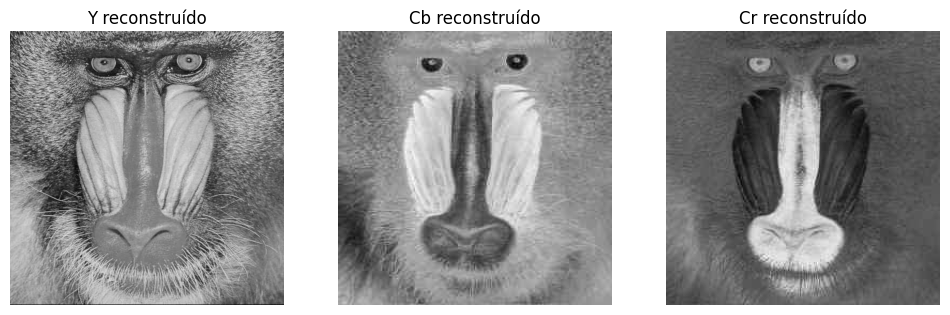

In [49]:
def reconstruir_matriz_de_blocos(blocos, altura, largura, tamanho_bloco=8):
    """
    Reconstrói uma matriz 2D a partir de uma lista de blocos 8x8.
    Também soma 128 para desfazer a normalização feita antes da DCT.
    """

    matriz = np.zeros((altura, largura))

    indice = 0

    for i in range(0, altura, tamanho_bloco):
        for j in range(0, largura, tamanho_bloco):
            matriz[i:i+tamanho_bloco, j:j+tamanho_bloco] = blocos[indice]
            indice += 1

    matriz = matriz + 128
    matriz = np.clip(matriz, 0, 255)

    return matriz


altura_Y, largura_Y = Y.shape
altura_Cb, largura_Cb = Cb_sub.shape
altura_Cr, largura_Cr = Cr_sub.shape

Y_rec = reconstruir_matriz_de_blocos(blocos_Y_idct, altura_Y, largura_Y)
Cb_sub_rec = reconstruir_matriz_de_blocos(blocos_Cb_idct, altura_Cb, largura_Cb)
Cr_sub_rec = reconstruir_matriz_de_blocos(blocos_Cr_idct, altura_Cr, largura_Cr)

print("Formato Y reconstruído:", Y_rec.shape)
print("Formato Cb reconstruído:", Cb_sub_rec.shape)
print("Formato Cr reconstruído:", Cr_sub_rec.shape)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(Y_rec, cmap="gray")
plt.title("Y reconstruído")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(Cb_sub_rec, cmap="gray")
plt.title("Cb reconstruído")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(Cr_sub_rec, cmap="gray")
plt.title("Cr reconstruído")
plt.axis("off")

plt.show()

In this step, the 8x8 blocks obtained after the inverse DCT are reorganized to reconstruct the Y, Cb and Cr channel matrices. The blocks are placed back into their original positions, forming the complete channel matrices.


## [8] Chroma Upsampling


Formato Y reconstruído: (512, 512)
Formato Cb antes da superamostragem: (256, 256)
Formato Cr antes da superamostragem: (256, 256)
Formato Cb depois da superamostragem: (512, 512)
Formato Cr depois da superamostragem: (512, 512)


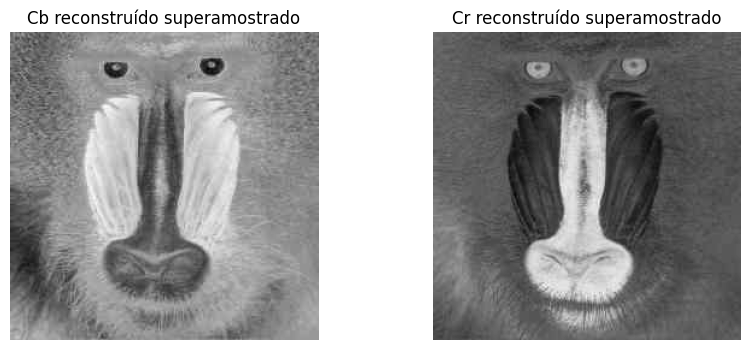

In [50]:
def superamostrar_420(Cb_sub, Cr_sub):
    """
    Faz a superamostragem 4:2:0 dos canais Cb e Cr.
    Cada pixel é replicado em um bloco 2x2.
    """

    Cb_rec = np.repeat(np.repeat(Cb_sub, 2, axis=0), 2, axis=1)
    Cr_rec = np.repeat(np.repeat(Cr_sub, 2, axis=0), 2, axis=1)

    return Cb_rec, Cr_rec


Cb_rec, Cr_rec = superamostrar_420(Cb_sub_rec, Cr_sub_rec)

print("Formato Y reconstruído:", Y_rec.shape)
print("Formato Cb antes da superamostragem:", Cb_sub_rec.shape)
print("Formato Cr antes da superamostragem:", Cr_sub_rec.shape)
print("Formato Cb depois da superamostragem:", Cb_rec.shape)
print("Formato Cr depois da superamostragem:", Cr_rec.shape)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(Cb_rec, cmap="gray")
plt.title("Cb reconstruído superamostrado")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(Cr_rec, cmap="gray")
plt.title("Cr reconstruído superamostrado")
plt.axis("off")

plt.show()

In this step, the reconstructed Y, Cb and Cr matrices are prepared for color-space conversion. Since the chrominance channels were subsampled during encoding, they must be upsampled before returning to RGB.


In this step, chroma subsampling is reversed. During encoding, Cb and Cr were reduced using the 4:2:0 format. During decoding, each subsampled value is replicated back into a 2x2 block to recover the original chrominance resolution.


## [9] YCbCr to RGB Conversion


Formato da imagem original: (512, 512, 3)
Formato da imagem reconstruída: (512, 512, 3)


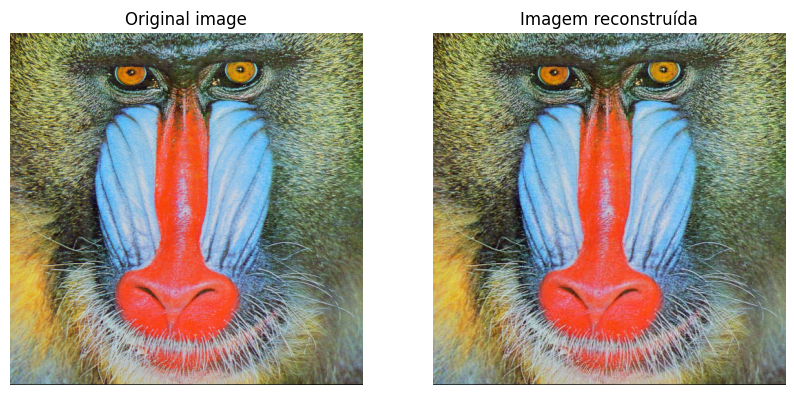

In [51]:
def ycbcr_para_rgb(Y, Cb, Cr):
    """
    Converte os canais Y, Cb e Cr reconstruídos para uma imagem RGB.
    """

    R = Y + 1.402 * (Cr - 128)
    G = Y - 0.344136 * (Cb - 128) - 0.714136 * (Cr - 128)
    B = Y + 1.772 * (Cb - 128)

    imagem_rgb_rec = np.stack((R, G, B), axis=2)

    imagem_rgb_rec = np.clip(imagem_rgb_rec, 0, 255)
    imagem_rgb_rec = imagem_rgb_rec.astype(np.uint8)

    return imagem_rgb_rec


imagem_rgb_rec = ycbcr_para_rgb(Y_rec, Cb_rec, Cr_rec)

print("Formato da imagem original:", imagem_rgb.shape)
print("Formato da imagem reconstruída:", imagem_rgb_rec.shape)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(imagem_rgb)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(imagem_rgb_rec)
plt.title("Imagem reconstruída")
plt.axis("off")

plt.show()

# Part 3 - Final Metrics and Parameter Study


In [52]:
pip install scikit-image

Note: you may need to restart the kernel to use updated packages.


## [1] Quality Metrics


In [53]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

def calcular_metricas_qualidade(imagem_original, imagem_reconstruida):
    """
    Calcula PSNR e SSIM entre a imagem original e a imagem reconstruída.
    """

    psnr = peak_signal_noise_ratio(
        imagem_original,
        imagem_reconstruida,
        data_range=255
    )

    ssim = structural_similarity(
        imagem_original,
        imagem_reconstruida,
        channel_axis=2,
        data_range=255
    )

    print("===== Quality Metrics =====")
    print(f"PSNR: {psnr:.2f} dB")
    print(f"SSIM: {ssim:.4f}")

    print("\nComments:")
    print("PSNR measures the average error between the original and reconstructed images.")
    print("The higher the PSNR, the lower the reconstruction error.")
    print("SSIM measures the structural similarity between the images.")
    print("The closer SSIM is to 1, the more similar the reconstructed image is to the original.")

    return psnr, ssim

In [54]:
psnr_Q50, ssim_Q50 = calcular_metricas_qualidade(imagem_rgb, imagem_rgb_rec)

===== Quality Metrics =====
PSNR: 25.08 dB
SSIM: 0.7974

Comments:
PSNR measures the average error between the original and reconstructed images.
The higher the PSNR, the lower the reconstruction error.
SSIM measures the structural similarity between the images.
The closer SSIM is to 1, the more similar the reconstructed image is to the original.


In this step, objective metrics are computed to evaluate the quality of the reconstructed image after compression and decoding. Two metrics are used: PSNR and SSIM. PSNR measures the ratio between the maximum possible pixel value and the mean squared reconstruction error. SSIM evaluates structural similarity between the original and reconstructed images.


## [2] Parameters and Subjective Evaluation


In [55]:
def executar_codec_jpeg(imagem_rgb, Q, nome_tabela):
    """
    Runs the simplified JPEG encoding and decoding pipeline using a quantization matrix Q.
    Returns the reconstructed image, the bitstream and the main metrics.
    """

    # =========================
    # ENCODING
    # =========================

    # RGB -> YCbCr
    Y, Cb, Cr = rgb_para_ycbcr(imagem_rgb)

    # 4:2:0 subsampling
    Cb_sub, Cr_sub = subamostrar_420(Cb, Cr)

    # 8x8 block conversion
    blocos_Y = converter_para_blocos(Y)
    blocos_Cb = converter_para_blocos(Cb_sub)
    blocos_Cr = converter_para_blocos(Cr_sub)

    # DCT
    blocos_Y_dct = aplicar_dct_blocos(blocos_Y, T)
    blocos_Cb_dct = aplicar_dct_blocos(blocos_Cb, T)
    blocos_Cr_dct = aplicar_dct_blocos(blocos_Cr, T)

    # Quantization with the selected Q matrix
    blocos_Y_q = quantizar_blocos(blocos_Y_dct, Q)
    blocos_Cb_q = quantizar_blocos(blocos_Cb_dct, Q)
    blocos_Cr_q = quantizar_blocos(blocos_Cr_dct, Q)

    # DPCM
    blocos_Y_dpcm = aplicar_dpcm(blocos_Y_q)
    blocos_Cb_dpcm = aplicar_dpcm(blocos_Cb_q)
    blocos_Cr_dpcm = aplicar_dpcm(blocos_Cr_q)

    # Zig-zag
    blocos_Y_zigzag = aplicar_zigzag_blocos(blocos_Y_dpcm)
    blocos_Cb_zigzag = aplicar_zigzag_blocos(blocos_Cb_dpcm)
    blocos_Cr_zigzag = aplicar_zigzag_blocos(blocos_Cr_dpcm)

    # Zero run-length encoding
    blocos_Y_rle = aplicar_corrida_zeros_blocos(blocos_Y_zigzag)
    blocos_Cb_rle = aplicar_corrida_zeros_blocos(blocos_Cb_zigzag)
    blocos_Cr_rle = aplicar_corrida_zeros_blocos(blocos_Cr_zigzag)

    blocos_rle = blocos_Y_rle + blocos_Cb_rle + blocos_Cr_rle

    # Huffman
    bitstream, tree = huffman.encode_huffman(blocos_rle)

    # =========================
    # DEENCODING
    # =========================

    # Inverse Huffman
    blocos_rle_dec = huffman.decode_huffman(bitstream, tree)

    # Zero run-length encoding inversa
    blocos_vetores_dec = decodificar_corrida_zeros_blocos(blocos_rle_dec)

    # Zig-zag inverso
    blocos_matrizes_dec = aplicar_zigzag_inverso_blocos(blocos_vetores_dec)

    # Channel separation
    nY = len(blocos_Y_q)
    nCb = len(blocos_Cb_q)
    nCr = len(blocos_Cr_q)

    blocos_Y_dec = blocos_matrizes_dec[:nY]
    blocos_Cb_dec = blocos_matrizes_dec[nY:nY+nCb]
    blocos_Cr_dec = blocos_matrizes_dec[nY+nCb:nY+nCb+nCr]

    # Inverse DPCM
    blocos_Y_dpcm_inv = aplicar_dpcm_inversa(blocos_Y_dec)
    blocos_Cb_dpcm_inv = aplicar_dpcm_inversa(blocos_Cb_dec)
    blocos_Cr_dpcm_inv = aplicar_dpcm_inversa(blocos_Cr_dec)

    # Dequantização
    blocos_Y_deq = dequantizar_blocos(blocos_Y_dpcm_inv, Q)
    blocos_Cb_deq = dequantizar_blocos(blocos_Cb_dpcm_inv, Q)
    blocos_Cr_deq = dequantizar_blocos(blocos_Cr_dpcm_inv, Q)

    # IDCT
    blocos_Y_idct = aplicar_idct_blocos(blocos_Y_deq, T)
    blocos_Cb_idct = aplicar_idct_blocos(blocos_Cb_deq, T)
    blocos_Cr_idct = aplicar_idct_blocos(blocos_Cr_deq, T)

    # Matrix reconstruction
    Y_rec = reconstruir_matriz_de_blocos(blocos_Y_idct, Y.shape[0], Y.shape[1])
    Cb_sub_rec = reconstruir_matriz_de_blocos(blocos_Cb_idct, Cb_sub.shape[0], Cb_sub.shape[1])
    Cr_sub_rec = reconstruir_matriz_de_blocos(blocos_Cr_idct, Cr_sub.shape[0], Cr_sub.shape[1])

    # Upsampling
    Cb_rec, Cr_rec = superamostrar_420(Cb_sub_rec, Cr_sub_rec)

    # YCbCr -> RGB
    imagem_rec = ycbcr_para_rgb(Y_rec, Cb_rec, Cr_rec)

    # =========================
    # MÉTRICAS
    # =========================

    altura, largura, canais = imagem_rgb.shape

    tamanho_original_bits = altura * largura * canais * 8
    tamanho_comprimido_bits = len(bitstream)

    razao_compressao = tamanho_original_bits / tamanho_comprimido_bits
    bpp = tamanho_comprimido_bits / (altura * largura)

    psnr = peak_signal_noise_ratio(
        imagem_rgb,
        imagem_rec,
        data_range=255
    )

    ssim = structural_similarity(
        imagem_rgb,
        imagem_rec,
        channel_axis=2,
        data_range=255
    )

    print(f"===== Resultados para {nome_tabela} =====")
    print(f"Original size: {tamanho_original_bits} bits")
    print(f"Tamanho comprimido: {tamanho_comprimido_bits} bits")
    print(f"Compression ratio: {razao_compressao:.2f}:1")
    print(f"Bits per pixel: {bpp:.4f} bpp")
    print(f"PSNR: {psnr:.2f} dB")
    print(f"SSIM: {ssim:.4f}")
    print()

    return {
        "nome": nome_tabela,
        "imagem": imagem_rec,
        "bitstream": bitstream,
        "razao_compressao": razao_compressao,
        "bpp": bpp,
        "psnr": psnr,
        "ssim": ssim
    }

In [56]:
Q10, Q50, Q90 = utils.q_tables()
resultado_Q10 = executar_codec_jpeg(imagem_rgb, Q10, "Q10")
resultado_Q50 = executar_codec_jpeg(imagem_rgb, Q50, "Q50")
resultado_Q90 = executar_codec_jpeg(imagem_rgb, Q90, "Q90")

===== Resultados para Q10 =====
Original size: 6291456 bits
Tamanho comprimido: 284937 bits
Compression ratio: 22.08:1
Bits per pixel: 1.0869 bpp
PSNR: 23.65 dB
SSIM: 0.7350

===== Resultados para Q50 =====
Original size: 6291456 bits
Tamanho comprimido: 462143 bits
Compression ratio: 13.61:1
Bits per pixel: 1.7629 bpp
PSNR: 25.08 dB
SSIM: 0.7974

===== Resultados para Q90 =====
Original size: 6291456 bits
Tamanho comprimido: 711949 bits
Compression ratio: 8.84:1
Bits per pixel: 2.7159 bpp
PSNR: 26.53 dB
SSIM: 0.8434



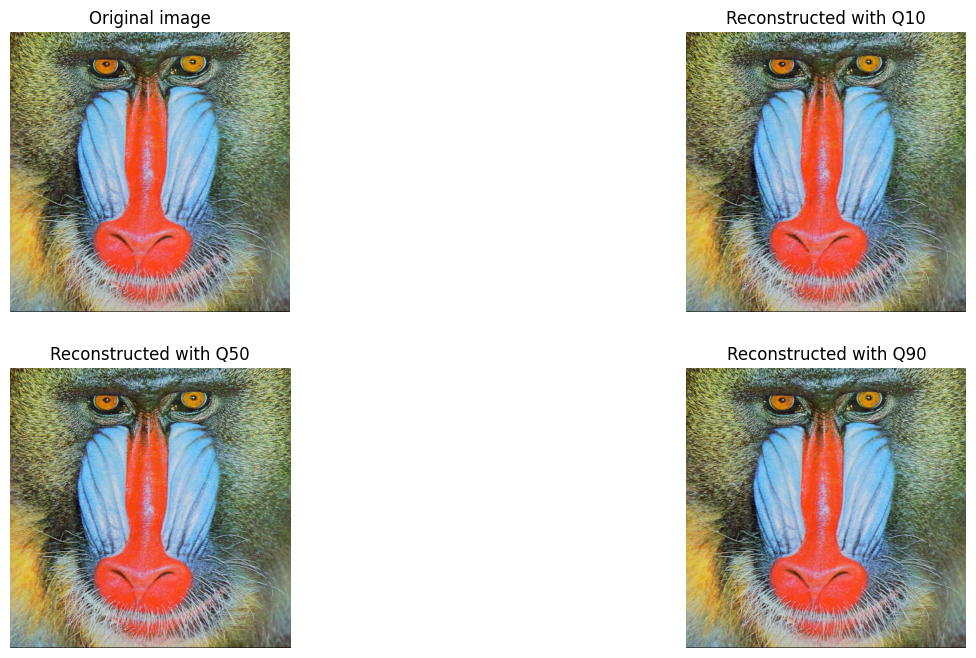

In [57]:
plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
plt.imshow(imagem_rgb)
plt.title("Original image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(resultado_Q10["imagem"])
plt.title("Reconstructed with Q10")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(resultado_Q50["imagem"])
plt.title("Reconstructed with Q50")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(resultado_Q90["imagem"])
plt.title("Reconstructed with Q90")
plt.axis("off")

plt.show()

In [58]:
import pandas as pd

resultados = [resultado_Q10, resultado_Q50, resultado_Q90]

tabela_resultados = pd.DataFrame({
    "Table": [r["nome"] for r in resultados],
    "Compression ratio": [r["razao_compressao"] for r in resultados],
    "BPP": [r["bpp"] for r in resultados],
    "PSNR (dB)": [r["psnr"] for r in resultados],
    "SSIM": [r["ssim"] for r in resultados],
    "Bitstream size": [len(r["bitstream"]) for r in resultados]
})

display(tabela_resultados)

,Table,Compression ratio,BPP,PSNR (dB),SSIM,Bitstream size
0,Q10,22.080165,1.086948,23.646325,0.735025,284937
1,Q50,13.613656,1.762936,25.075733,0.797363,462143
2,Q90,8.836948,2.715870,26.530364,0.843361,711949


In [59]:
def comentar_resultados_parametros():
    print("===== Comentários sobre os parâmetros de quantização =====")
    print()
    print("A matriz Q10 possui valores de quantização mais altos.")
    print("Isso faz com que muitos coeficientes da DCT sejam reduzidos ou zerados após a quantização.")
    print("Como consequência, a compressão tende a ser maior, mas a qualidade visual da imagem reconstruída tende a ser menor.")
    print()
    print("A matriz Q50 representa uma situação intermediária.")
    print("Ela busca equilibrar taxa de compressão e preservação da qualidade visual.")
    print()
    print("A matriz Q90 possui valores menores em comparação com Q10.")
    print("Isso preserva mais coeficientes da DCT, especialmente os de frequências mais altas.")
    print("Como consequência, a qualidade visual tende a ser maior, mas a compressão tende a ser menor.")
    print()
    print("Na prática, os níveis de quantização permitem ajustar o compromisso entre tamanho do arquivo e qualidade da imagem.")
    print("Quando se deseja economizar mais espaço ou transmitir menos bits, usa-se uma quantização mais forte.")
    print("Quando se deseja preservar melhor os detalhes visuais, usa-se uma quantização mais fraca.")
    print()
    print("Assim, a escolha da matriz de quantização depende da aplicação: armazenamento, transmissão, visualização rápida ou preservação de qualidade.")

comentar_resultados_parametros()

===== Comentários sobre os parâmetros de quantização =====

A matriz Q10 possui valores de quantização mais altos.
Isso faz com que muitos coeficientes da DCT sejam reduzidos ou zerados após a quantização.
Como consequência, a compressão tende a ser maior, mas a qualidade visual da imagem reconstruída tende a ser menor.

A matriz Q50 representa uma situação intermediária.
Ela busca equilibrar taxa de compressão e preservação da qualidade visual.

A matriz Q90 possui valores menores em comparação com Q10.
Isso preserva mais coeficientes da DCT, especialmente os de frequências mais altas.
Como consequência, a qualidade visual tende a ser maior, mas a compressão tende a ser menor.

Na prática, os níveis de quantização permitem ajustar o compromisso entre tamanho do arquivo e qualidade da imagem.
Quando se deseja economizar mais espaço ou transmitir menos bits, usa-se uma quantização mais forte.
Quando se deseja preservar melhor os detalhes visuais, usa-se uma quantização mais fraca.

Assi

In this step, the effect of the quantization matrix on reconstructed image quality and compression rate is analyzed. The simplified JPEG codec is executed three times using Q10, Q50 and Q90. Stronger quantization generally increases compression but reduces visual quality, while weaker quantization preserves more detail at the cost of a larger bitstream.
